In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [66]:
import os
df = pd.read_csv("../data/row/WA_Fn-UseC_-Telco-Customer-Churn"
".csv")

In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.shape

(7043, 21)

In [18]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [21]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [68]:
df.drop("customerID", axis=1, inplace=True)

In [72]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({
    1: 'Yes',
    0: 'No'
})

print(df.head())

   gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female           NaN     Yes         No       1           No   
1    Male           NaN      No         No      34          Yes   
2    Male           NaN      No         No       2          Yes   
3    Male           NaN      No         No      45           No   
4  Female           NaN      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No        

In [70]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [71]:
df["TotalCharges"].dtype

dtype('float64')

In [26]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [27]:
df.dropna(inplace=True)

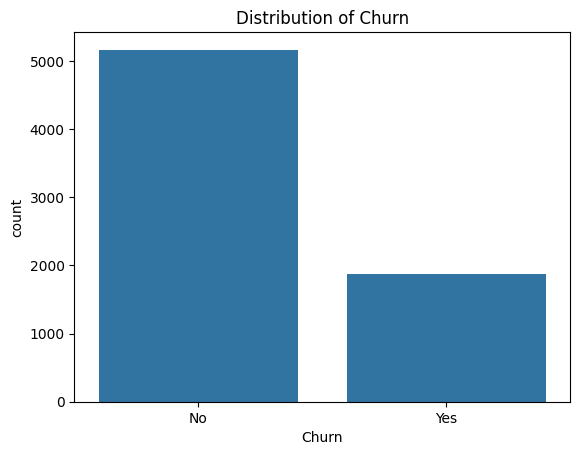

In [30]:
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.show()

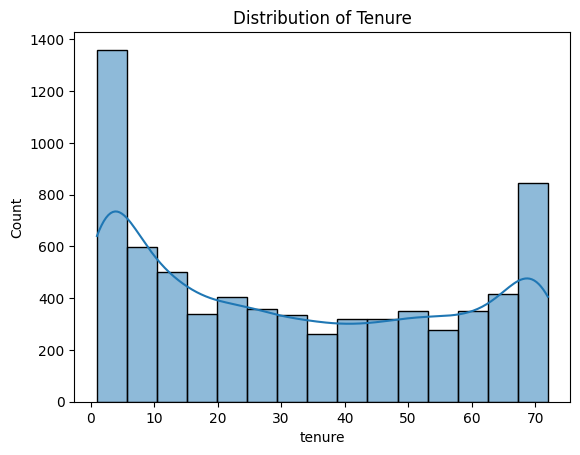

In [31]:
sns.histplot(df["tenure"], kde=True)
plt.title("Distribution of Tenure")
plt.show()

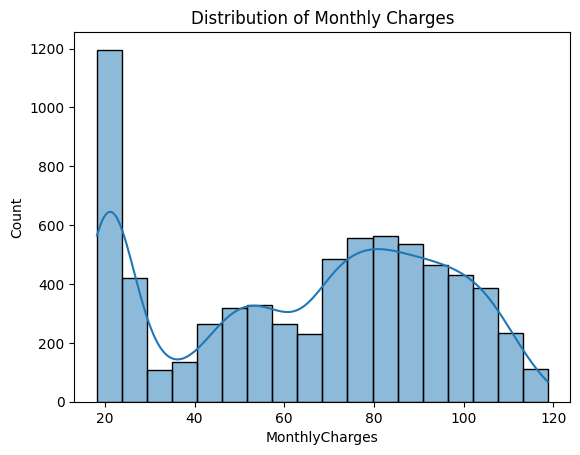

In [32]:
sns.histplot(df["MonthlyCharges"] , kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

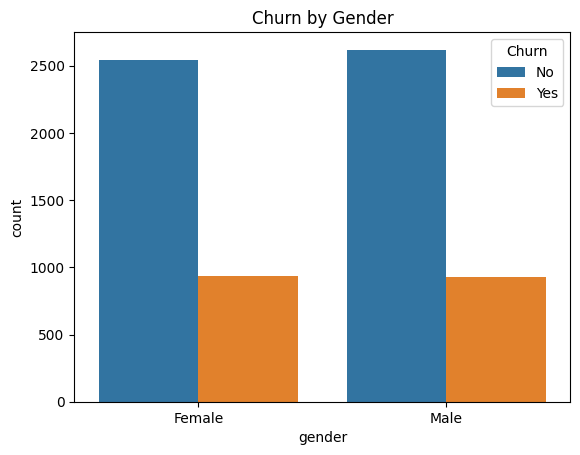

In [35]:
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Churn by Gender")
plt.show()

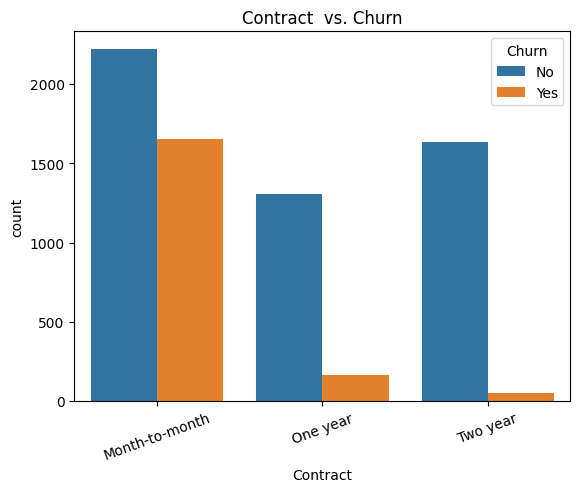

In [40]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract  vs. Churn")
plt.xticks(rotation=20)
plt.show()


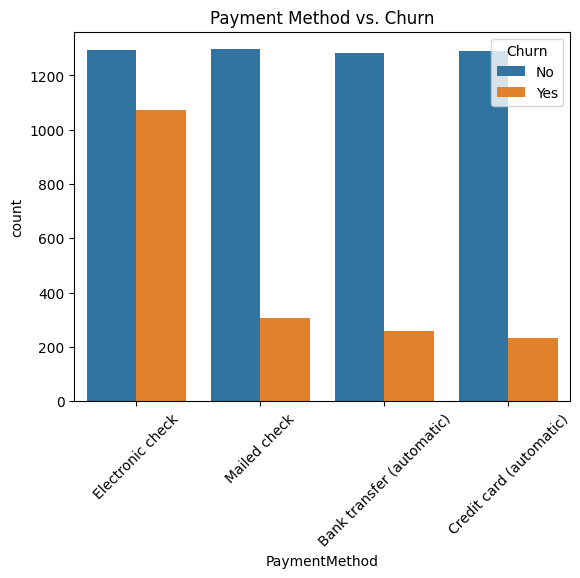

In [42]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs. Churn")
plt.xticks(rotation=45)
plt.show()

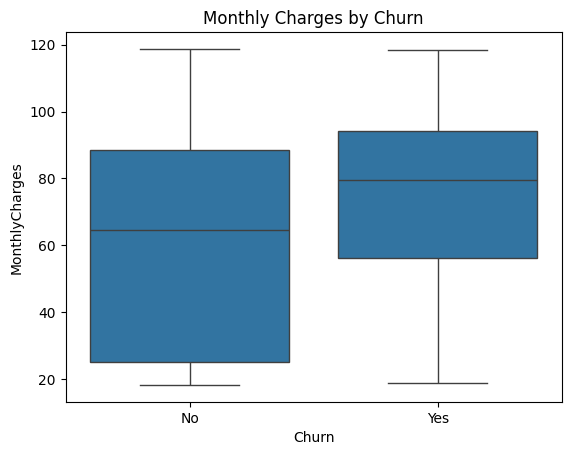

In [43]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges by Churn")
plt.show()

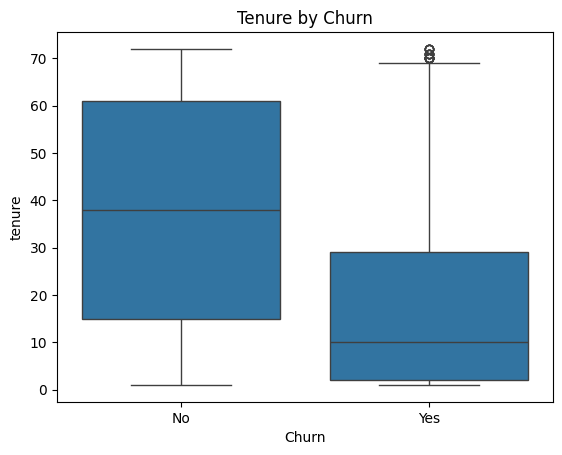

In [44]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure by Churn")
plt.show()

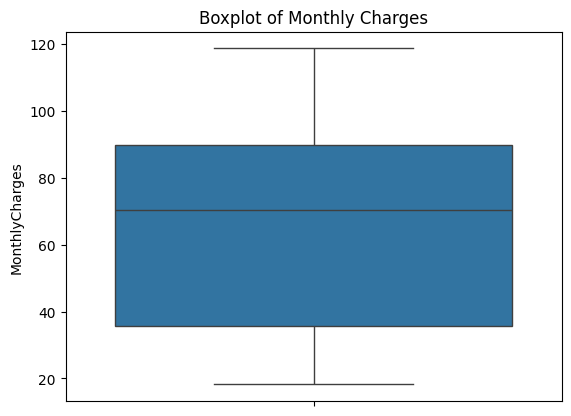

In [46]:
sns.boxplot(df['MonthlyCharges'])
plt.title("Boxplot of Monthly Charges")
plt.show()

In [ ]:
# Insights

# 1. Customers with month-to-month contracts churn more.
# 2. High monthly charges are associated with churn.
# 3. Customers with short tenure are more likely to churn.
# 4. Fiber optic users have higher churn rate.

In [78]:
df.to_csv('../data/row/cleaned.csv', index=False)